In [8]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.api import OLS, add_constant

In [2]:
# Define the ticker symbols
bbri_ticker_symbol = 'BBRI.JK'  # BBRI on the Jakarta Stock Exchange
ihsg_ticker_symbol = '^JKSE'    # IHSG index on Yahoo Finance

# Get data for BBRI
bbri_data = yf.Ticker(bbri_ticker_symbol)
bbri = bbri_data.history(period="max")
bbri.reset_index(inplace=True)

# Get data for IHSG
ihsg_data = yf.Ticker(ihsg_ticker_symbol)
ihsg = ihsg_data.history(start=bbri['Date'].min(), end=bbri['Date'].max())  # Ensure same period
ihsg.reset_index(inplace=True)

# Merge IHSG data into BBRI dataframe based on the date
bbri = bbri.merge(ihsg[['Date', 'Close']], on='Date', how='left', suffixes=('', '_IHSG'))

In [3]:
bbri = bbri.drop(columns=['Open', 'High', 'Low'])
bbri

,Date,Close,Volume,Dividends,Stock Splits,Close_IHSG
0,2003-11-10 00:00:00+07:00,43.729198,5658651738,0.0,0.0,620.045837
1,2003-11-11 00:00:00+07:00,44.850452,3232466332,0.0,0.0,617.693909
2,2003-11-12 00:00:00+07:00,47.092968,2203244555,0.0,0.0,619.847900
3,2003-11-13 00:00:00+07:00,47.092968,1309077610,0.0,0.0,614.612061
4,2003-11-14 00:00:00+07:00,47.092968,1897824280,0.0,0.0,610.311279
...,...,...,...,...,...,...
5137,2024-08-07 00:00:00+07:00,4620.000000,125937500,0.0,0.0,7212.130859
5138,2024-08-08 00:00:00+07:00,4660.000000,131343400,0.0,0.0,7195.121094
5139,2024-08-09 00:00:00+07:00,4670.000000,98730900,0.0,0.0,7256.996094
5140,2024-08-12 00:00:00+07:00,4680.000000,83552800,0.0,0.0,7297.625000


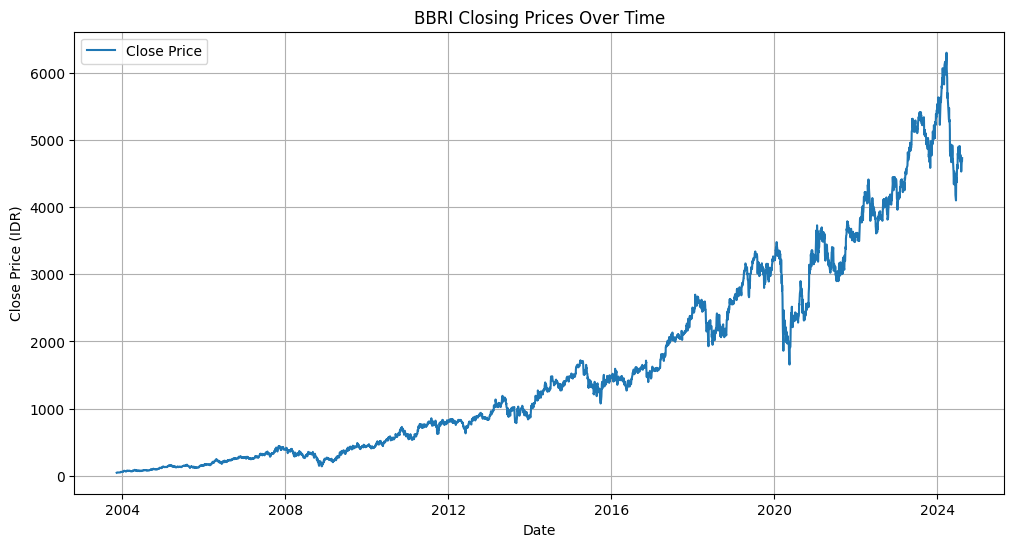

In [4]:
# Plotting the closing prices over time
plt.figure(figsize=(12, 6))
plt.plot(bbri['Date'], bbri['Close'], label='Close Price')
plt.xlabel('Date')
plt.ylabel('Close Price (IDR)')
plt.title('BBRI Closing Prices Over Time')
plt.legend()
plt.grid(True)
plt.show()

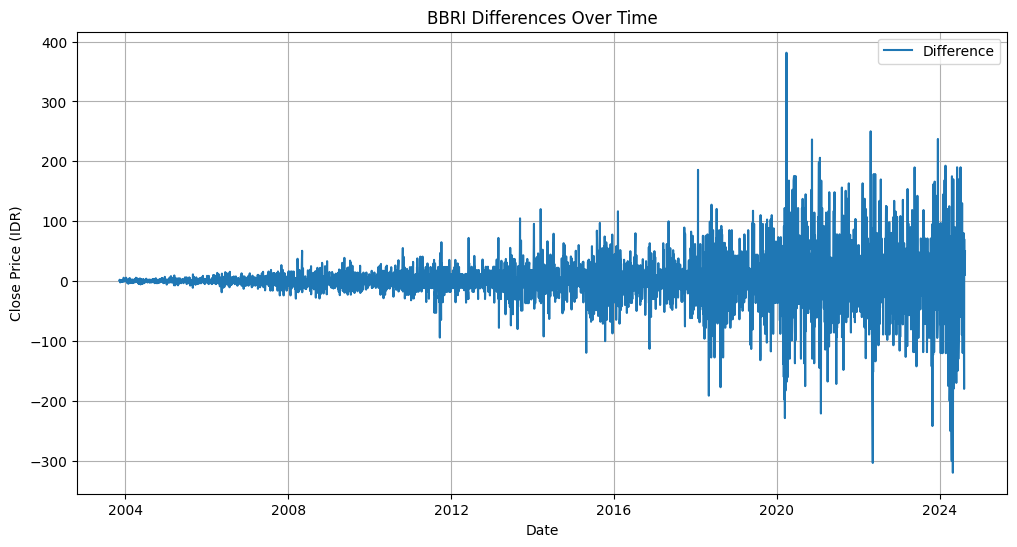

In [5]:
# Plotting the closing prices over time
plt.figure(figsize=(12, 6))
plt.plot(bbri['Date'].iloc[1:], bbri['Close'].diff().iloc[1:], label='Difference')
plt.xlabel('Date')
plt.ylabel('Close Price (IDR)')
plt.title('BBRI Differences Over Time')
plt.legend()
plt.grid(True)
plt.show()

In [6]:
bbri.to_csv('dataset/bbri_stockprice.csv', index=False)

# Market

In [10]:
# Calculate daily returns for the stock and the market
bbri['stock_return'] = bbri['Close'].pct_change(fill_method=None)
bbri['market_return'] = bbri['Close_IHSG'].pct_change(fill_method=None)

# Drop NaN values caused by pct_change
bbri.dropna(inplace=True)

In [12]:
# Estimate normal returns using the market model
market_model = OLS(bbri['stock_return'], add_constant(bbri['market_return'])).fit()
bbri['expected_return'] = market_model.predict(add_constant(bbri['market_return']))

In [13]:
# Calculate abnormal returns
bbri['abnormal_return'] = bbri['stock_return'] - bbri['expected_return']

# Determine threshold for abnormality (e.g., returns outside 2 standard deviations are abnormal)
threshold = 2 * bbri['abnormal_return'].std()
bbri['label'] = (abs(bbri['abnormal_return']) > threshold).astype(int)

In [18]:
bbri

,Date,Close,Volume,Dividends,Stock Splits,Close_IHSG,stock_return,market_return,expected_return,abnormal_return,label
2,2003-11-12 00:00:00+07:00,47.092968,2203244555,0.0,0.0,619.847900,0.050000,0.003487,0.005294,0.044706,1
3,2003-11-13 00:00:00+07:00,47.092968,1309077610,0.0,0.0,614.612061,0.000000,-0.008447,-0.011377,0.011377,0
4,2003-11-14 00:00:00+07:00,47.092968,1897824280,0.0,0.0,610.311279,0.000000,-0.006998,-0.009352,0.009352,0
5,2003-11-17 00:00:00+07:00,44.850452,465863546,0.0,0.0,607.765381,-0.047619,-0.004171,-0.005404,-0.042214,1
6,2003-11-18 00:00:00+07:00,43.729198,437868063,0.0,0.0,605.763367,-0.025000,-0.003294,-0.004179,-0.020821,0
...,...,...,...,...,...,...,...,...,...,...,...
5136,2024-08-06 00:00:00+07:00,4600.000000,238051800,0.0,0.0,7129.214844,0.015453,0.009853,0.014187,0.001265,0
5137,2024-08-07 00:00:00+07:00,4620.000000,125937500,0.0,0.0,7212.130859,0.004348,0.011630,0.016670,-0.012322,0
5138,2024-08-08 00:00:00+07:00,4660.000000,131343400,0.0,0.0,7195.121094,0.008658,-0.002358,-0.002872,0.011530,0
5139,2024-08-09 00:00:00+07:00,4670.000000,98730900,0.0,0.0,7256.996094,0.002146,0.008600,0.012436,-0.010290,0


In [15]:
export_df = bbri.drop(columns=['Volume', 'Dividends', 'Stock Splits', 'Close_IHSG', 
                               'stock_return', 'market_return', 'expected_return', 'abnormal_return'])

In [17]:
export_df.to_csv('dataset/stockprice_abnormal_labeled.csv', index=False)